# Fashion-MNIST Image Classification with a CNN

**Milestone 2 — AI for Non-tabular Data | Deep Learning**

This notebook builds, trains, and evaluates a convolutional neural network (CNN) that classifies 28×28 grayscale clothing images into 10 categories. It covers data sourcing, preprocessing, train/validation/test splitting, model development, training monitoring, and evaluation with a confusion matrix and classification report.

**Research question:** How accurately can a compact CNN classify previously unseen Fashion-MNIST images?

## 1. Setup and reproducibility

Fashion-MNIST is included with Keras and downloads automatically from a public source. Seeds are fixed where practical, although small differences can remain across hardware and TensorFlow versions.

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

CLASS_NAMES = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
print('TensorFlow version:', tf.__version__)
print('GPU available:', bool(tf.config.list_physical_devices('GPU')))

TensorFlow version: 2.20.0
GPU available: True


## 2. Data sourcing and inspection

Fashion-MNIST contains 70,000 labelled product images across 10 balanced categories. Keras provides an official 60,000-image training set and a separate 10,000-image test set. The test set will remain untouched until final evaluation.

In [2]:
(x_full, y_full), (x_test_raw, y_test) = tf.keras.datasets.fashion_mnist.load_data()
print('Official training set:', x_full.shape, y_full.shape)
print('Official test set:', x_test_raw.shape, y_test.shape)
print('Pixel range:', x_full.min(), 'to', x_full.max())
print('Class counts:', dict(zip(CLASS_NAMES, np.bincount(y_full))))

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Official training set: (60000, 28, 28) (60000,)
Official test set: (10000, 28, 28) (10000,)
Pixel range: 0 to 255
Class counts: {'T-shirt/top': np.int64(6000), 'Trouser': np.int64(6000), 'Pullover': np.int64(6000), 'Dress': np.int64(6000), 'Coat': np.int64(6000), 'Sandal': np.int64(6000), 'Shirt': np.int64(6000), 'Sneaker': np.int64(6000), 'Bag': np.int64(6000), 'Ankle boot': np.int64(6000)}


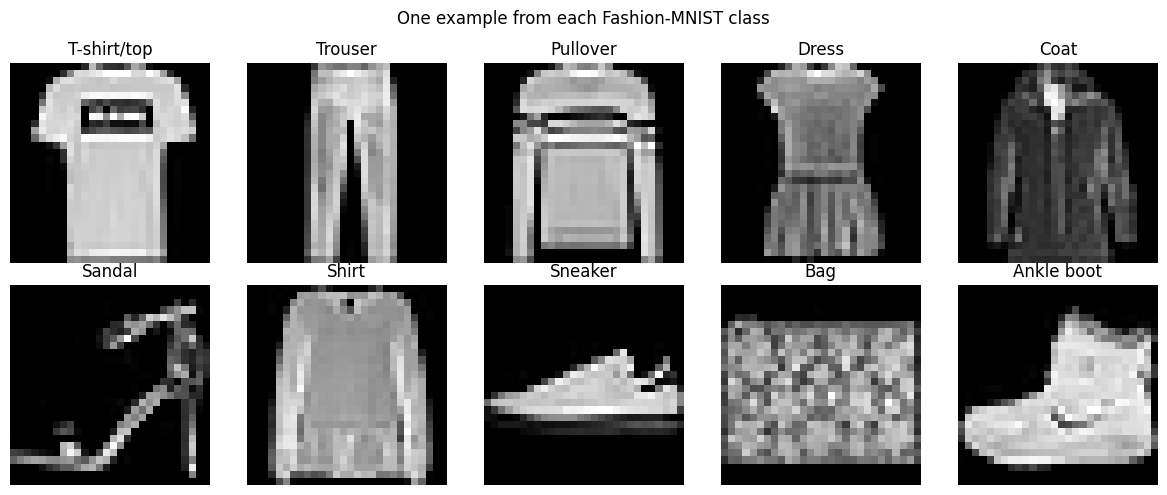

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for class_id, ax in enumerate(axes.flat):
    index = np.where(y_full == class_id)[0][0]
    ax.imshow(x_full[index], cmap='gray')
    ax.set_title(CLASS_NAMES[class_id])
    ax.axis('off')
plt.suptitle('One example from each Fashion-MNIST class')
plt.tight_layout()
plt.show()

## 3. Data preparation

The official training data is divided deterministically into 50,000 training images and 10,000 validation images. Pixel values are cast to `float32` and normalised from `[0, 255]` to `[0, 1]`. A channel dimension is added because `Conv2D` expects `(height, width, channels)`. Resizing is unnecessary because every image already has the consistent target size of 28×28.

In [4]:
x_train_raw, y_train = x_full[:50000], y_full[:50000]
x_val_raw, y_val = x_full[50000:], y_full[50000:]

def prepare_images(images):
    return np.expand_dims(images.astype('float32') / 255.0, axis=-1)

x_train = prepare_images(x_train_raw)
x_val = prepare_images(x_val_raw)
x_test = prepare_images(x_test_raw)

print(f'Training:   {x_train.shape}, labels: {y_train.shape}')
print(f'Validation: {x_val.shape}, labels: {y_val.shape}')
print(f'Test:       {x_test.shape}, labels: {y_test.shape}')
print(f'Normalised range: {x_train.min():.1f} to {x_train.max():.1f}')

Training:   (50000, 28, 28, 1), labels: (50000,)
Validation: (10000, 28, 28, 1), labels: (10000,)
Test:       (10000, 28, 28, 1), labels: (10000,)
Normalised range: 0.0 to 1.0


## 4. CNN model development

Convolutional layers learn local visual features such as edges and textures. Batch normalisation stabilises training, max pooling reduces spatial size, and dropout helps control overfitting. The final softmax layer returns a probability for each of the 10 classes.

In [5]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),
    tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Dropout(0.30),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.40),
    tf.keras.layers.Dense(10, activation='softmax')
], name='fashion_mnist_cnn')

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "fashion_mnist_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 468,202 (1.79 MB)

 Trainable params: 468,010 (1.79 MB)

 Non-trainable params: 192 (768.00 B)

## 5. Training and validation monitoring

The model can train for up to 15 epochs. Early stopping restores the weights from the epoch with the lowest validation loss, while learning-rate reduction helps refine learning if progress stalls.

In [6]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5, verbose=1)
]

history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=15,
    batch_size=128,
    callbacks=callbacks,
    verbose=2
)

Epoch 1/15
391/391 - 19s - 48ms/step - accuracy: 0.7426 - loss: 0.7221 - val_accuracy: 0.7230 - val_loss: 0.7975 - learning_rate: 0.0010
Epoch 2/15
391/391 - 4s - 9ms/step - accuracy: 0.8430 - loss: 0.4319 - val_accuracy: 0.8874 - val_loss: 0.3089 - learning_rate: 0.0010
Epoch 3/15
391/391 - 4s - 10ms/step - accuracy: 0.8700 - loss: 0.3611 - val_accuracy: 0.8960 - val_loss: 0.2799 - learning_rate: 0.0010
Epoch 4/15
391/391 - 4s - 9ms/step - accuracy: 0.8826 - loss: 0.3238 - val_accuracy: 0.9078 - val_loss: 0.2494 - learning_rate: 0.0010
Epoch 5/15
391/391 - 4s - 9ms/step - accuracy: 0.8911 - loss: 0.3030 - val_accuracy: 0.9120 - val_loss: 0.2402 - learning_rate: 0.0010
Epoch 6/15
391/391 - 4s - 10ms/step - accuracy: 0.8970 - loss: 0.2838 - val_accuracy: 0.9194 - val_loss: 0.2276 - learning_rate: 0.0010
Epoch 7/15
391/391 - 4s - 9ms/step - accuracy: 0.9031 - loss: 0.2677 - val_accuracy: 0.9170 - val_loss: 0.2332 - learning_rate: 0.0010
Epoch 8/15
391/391 - 4s - 9ms/step - accuracy: 0.90

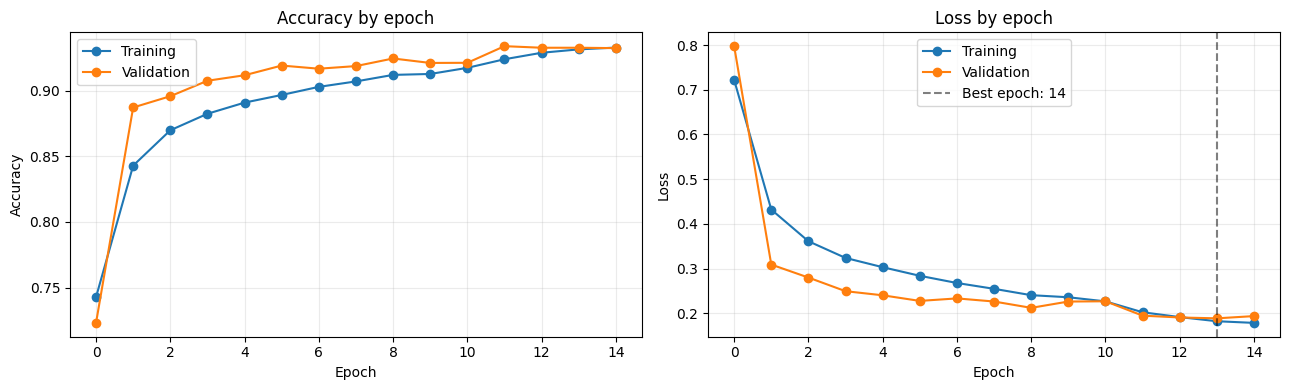

Best epoch by validation loss: 14


In [7]:
best_epoch = int(np.argmin(history.history['val_loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history.history['accuracy'], marker='o', label='Training')
axes[0].plot(history.history['val_accuracy'], marker='o', label='Validation')
axes[0].set(title='Accuracy by epoch', xlabel='Epoch', ylabel='Accuracy')
axes[0].legend(); axes[0].grid(alpha=0.25)
axes[1].plot(history.history['loss'], marker='o', label='Training')
axes[1].plot(history.history['val_loss'], marker='o', label='Validation')
axes[1].axvline(best_epoch - 1, color='black', linestyle='--', alpha=0.5, label=f'Best epoch: {best_epoch}')
axes[1].set(title='Loss by epoch', xlabel='Epoch', ylabel='Loss')
axes[1].legend(); axes[1].grid(alpha=0.25)
plt.tight_layout()
plt.show()
print('Best epoch by validation loss:', best_epoch)

## 6. Final evaluation on unseen test data

The test set is evaluated only after training decisions are complete. Accuracy provides an overall measure, while the classification report and confusion matrix reveal class-specific strengths and errors.

In [8]:
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
probabilities = model.predict(x_test, verbose=0)
predictions = probabilities.argmax(axis=1)
print(f'Test loss: {test_loss:.4f}')
print(f'Test accuracy: {test_accuracy:.2%}')

Test loss: 0.2096
Test accuracy: 92.81%


In [9]:
print('Classification report:\n')
print(classification_report(y_test, predictions, target_names=CLASS_NAMES, digits=4))

Classification report:

              precision    recall  f1-score   support

 T-shirt/top     0.8930    0.8680    0.8803      1000
     Trouser     0.9990    0.9830    0.9909      1000
    Pullover     0.9401    0.8630    0.8999      1000
       Dress     0.9260    0.9380    0.9319      1000
        Coat     0.8526    0.9200    0.8850      1000
      Sandal     0.9880    0.9870    0.9875      1000
       Shirt     0.7610    0.7930    0.7767      1000
     Sneaker     0.9625    0.9750    0.9687      1000
         Bag     0.9950    0.9870    0.9910      1000
  Ankle boot     0.9787    0.9670    0.9728      1000

    accuracy                         0.9281     10000
   macro avg     0.9296    0.9281    0.9285     10000
weighted avg     0.9296    0.9281    0.9285     10000



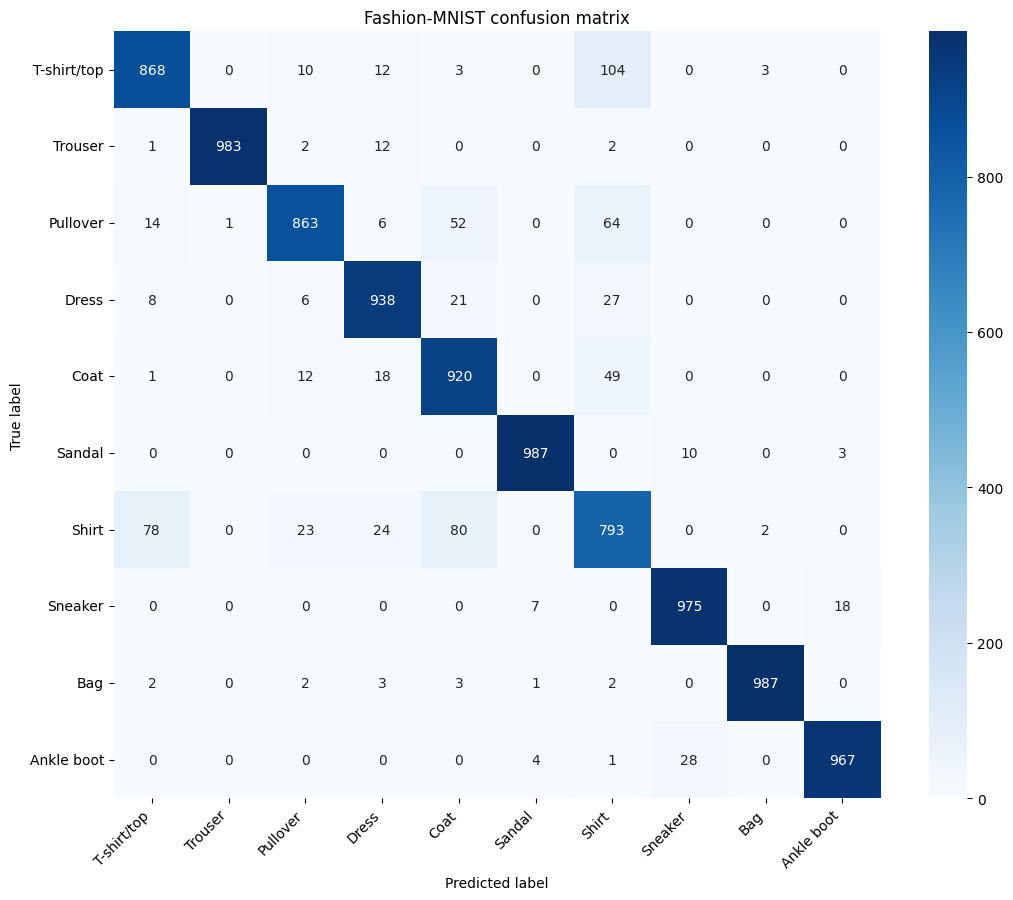

In [10]:
matrix = confusion_matrix(y_test, predictions)
plt.figure(figsize=(11, 9))
sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', square=True,
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Fashion-MNIST confusion matrix')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 7. Prediction examples and error analysis

Green titles indicate correct predictions and red titles indicate mistakes. Confidence is the maximum softmax probability.

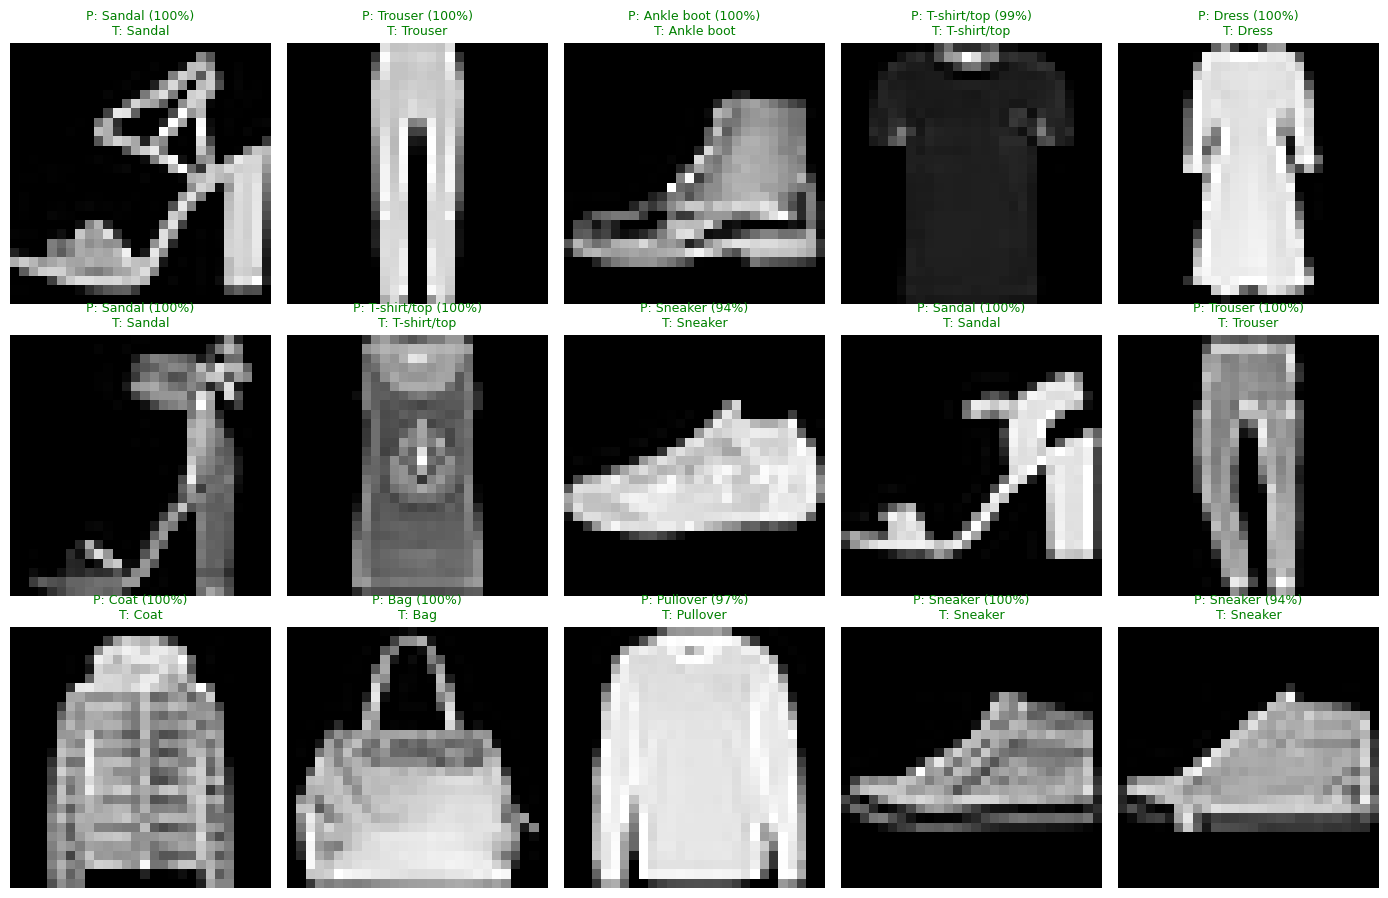

In [11]:
rng = np.random.default_rng(SEED)
sample_indices = rng.choice(len(x_test), size=15, replace=False)
fig, axes = plt.subplots(3, 5, figsize=(14, 9))
for index, ax in zip(sample_indices, axes.flat):
    predicted = predictions[index]
    actual = y_test[index]
    confidence = probabilities[index, predicted]
    ax.imshow(x_test[index].squeeze(), cmap='gray')
    ax.set_title(f'P: {CLASS_NAMES[predicted]} ({confidence:.0%})\nT: {CLASS_NAMES[actual]}',
                 color='green' if predicted == actual else 'red', fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

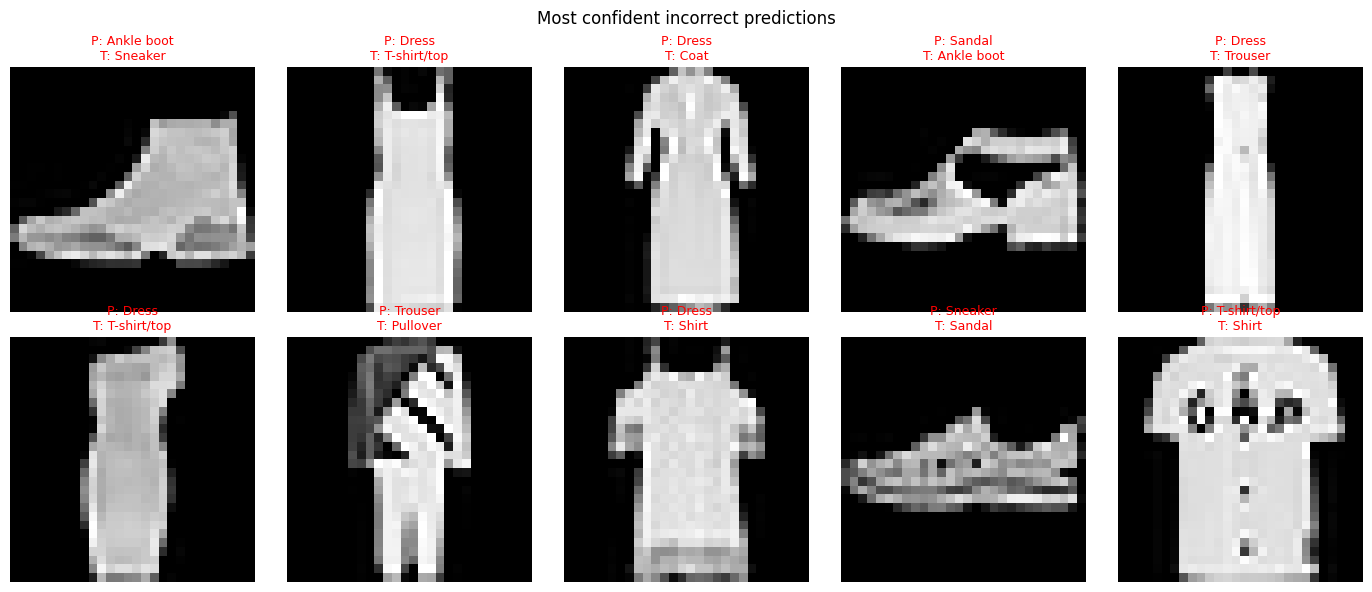

In [12]:
errors = np.where(predictions != y_test)[0]
if len(errors):
    confident_errors = errors[np.argsort(probabilities[errors].max(axis=1))[-10:]][::-1]
    fig, axes = plt.subplots(2, 5, figsize=(14, 6))
    for index, ax in zip(confident_errors, axes.flat):
        predicted, actual = predictions[index], y_test[index]
        ax.imshow(x_test[index].squeeze(), cmap='gray')
        ax.set_title(f'P: {CLASS_NAMES[predicted]}\nT: {CLASS_NAMES[actual]}', color='red', fontsize=9)
        ax.axis('off')
    plt.suptitle('Most confident incorrect predictions')
    plt.tight_layout()
    plt.show()

## 8. Conclusion and limitations

The final test accuracy printed above answers the research question. The confusion matrix should be used to identify the most difficult class pairs; visually similar upper-body garments—especially shirts, T-shirts/tops, pullovers, and coats—are expected to produce more confusion than distinctive classes such as bags and footwear.

Fashion-MNIST is a useful benchmark but is limited to low-resolution grayscale catalogue images. Performance should not be generalised directly to colour photographs or real deployment conditions. Possible improvements include data augmentation, systematic hyperparameter tuning, cross-validation, and comparison with transfer learning on a larger colour-image dataset.

In [13]:
model.save('fashion_mnist_cnn.keras')
print('Saved trained model to fashion_mnist_cnn.keras')

Saved trained model to fashion_mnist_cnn.keras


## References

1. Xiao, H., Rasul, K., & Vollgraf, R. (2017). *Fashion-MNIST: a Novel Image Dataset for Benchmarking Machine Learning Algorithms*. arXiv:1708.07747. https://arxiv.org/abs/1708.07747
2. TensorFlow. *Convolutional Neural Network (CNN)*. https://www.tensorflow.org/tutorials/images/cnn
3. scikit-learn. *Classification metrics*. https://scikit-learn.org/stable/modules/model_evaluation.html#classification-metrics